In [1]:
# import packages

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import keras
from keras import backend as K
from keras.layers import Input, Dense, Lambda
from keras.models import Model
from keras.callbacks import History
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import joblib
from sklearn.decomposition import PCA

2025-04-23 12:02:06.729498: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-23 12:02:08.844707: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-23 12:02:08.844755: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-23 12:02:08.979161: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-23 12:02:09.163371: I tensorflow/core/platform/cpu_feature_guar

## Import Data (scaled and sequential)

In [2]:
from numpy import asarray
from numpy import savetxt
from numpy import genfromtxt

scaled_input_ohc_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/data/ohc700_train_robustscaler.csv', delimiter=',')
scaled_input_ohc_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/data/ohc700_test_robustscaler.csv', delimiter=',')

scaled_input_sst_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/data/sst_train_robustscaler.csv', delimiter=',')
scaled_input_sst_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/data/sst_test_robustscaler.csv', delimiter=',')

scaled_input_olr_train = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_train_robustscaler.csv', delimiter=',')
scaled_input_olr_test = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_test_robustscaler.csv', delimiter=',')

In [3]:
# load netcdf files with time component 
sequential_input_ohc_train = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/data/ohc700_train_robustscaler.nc')
sequential_input_ohc_test = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/data/ohc700_test_robustscaler.nc')

sequential_input_olr_train = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_train_robustscaler.nc')
sequential_input_olr_test = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/olr_test_robustscaler.nc')

sequential_input_sst_train = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/data/sst_train_robustscaler.nc')
sequential_input_sst_test = xr.load_dataarray('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/data/sst_test_robustscaler.nc')

In [4]:
scaled_input_olr_train[:10]

array([[-0.13592516, -0.15422471, -0.10487127, ..., -1.00696635,
        -1.57224238, -1.56264472],
       [ 0.50404596,  0.48380584,  0.4865295 , ..., -1.05872321,
        -1.45092595, -1.42210627],
       [-1.40209067, -0.98124057, -0.6988914 , ...,  0.28162995,
         0.39260817,  0.49944344],
       ...,
       [-2.23494005, -2.02849984, -2.0067246 , ..., -0.69058853,
        -0.4744837 , -0.09201477],
       [ 0.03300727, -0.19273035, -0.47158346, ...,  0.36852723,
         0.29735371,  0.27511233],
       [ 0.46322525,  0.50955927,  0.54607534, ...,  0.74676704,
         1.0181216 ,  0.8303768 ]])

In [5]:
sequential_input_ohc_train[:10]

<xarray.DataArray (time: 10, newdim: 2960)> Size: 118kB
array([[-0.5098423 , -0.42624798, -0.4414991 , ..., -0.10636966,
        -0.08201101,  0.16111605],
       [ 0.18283269, -0.0807642 , -0.22554393, ...,  0.3262751 ,
         0.46502945,  0.4393872 ],
       [ 0.03460614, -0.03849565, -0.06131932, ...,  1.0091304 ,
         1.1257523 ,  1.1640763 ],
       ...,
       [-0.08057892,  0.06113308,  0.09547053, ..., -1.5105873 ,
        -1.4837941 , -1.5474393 ],
       [ 0.33354425,  0.32661927,  0.3541929 , ..., -0.06872585,
        -0.15307863, -0.27138838],
       [ 0.2751924 ,  0.00383303, -0.02056716, ..., -0.2376913 ,
        -0.20238823, -0.00821492]], dtype=float32)
Coordinates:
  * time     (time) object 80B 0282-10-01 00:00:00 ... 0100-10-01 00:00:00
    month    (time) int64 80B 10 8 1 7 2 5 1 2 10 10
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [6]:
# sanity checks
print(scaled_input_sst_train.shape,
     scaled_input_sst_test.shape,
     scaled_input_ohc_train.shape,
     scaled_input_ohc_test.shape,
     scaled_input_olr_train.shape,
     scaled_input_olr_test.shape)

(4800, 2968) (1200, 2968) (4800, 2960) (1200, 2960) (4800, 2662) (1200, 2662)


## Build Variational Autoencoder

In [94]:
# set random seed
keras.utils.set_random_seed(1)

In [95]:
# check input shape for sst
input_shape_sst = scaled_input_sst_train.shape[1]
print(input_shape_sst)

# check input shape for ssh
input_shape_ohc = scaled_input_ohc_train.shape[1]
print(input_shape_ohc)

# check input shape for zonal stress
input_shape_olr = scaled_input_olr_train.shape[1]
print(input_shape_olr)

2968
2960
2662


In [96]:
# define latent space (going to be 2 here)
latent_dim = 2

In [97]:
# sst input
input_sst = Input(shape=(np.int64(input_shape_sst),), name='input_sst')
print(input_sst.shape)

# add 2 dense layers
encoded_sst_layer1 = Dense(400, activation='tanh')(input_sst)
encoded_sst_layer2 = Dense(250, activation='tanh')(encoded_sst_layer1)
encoded_sst_layer3 = Dense(175, activation='tanh')(encoded_sst_layer2)
encoded_sst_layer4 = Dense(100, activation='tanh')(encoded_sst_layer3)
encoded_sst_layer5 = Dense(25, activation='tanh')(encoded_sst_layer4)

# ohc input
input_ohc = Input(shape=(np.int64(input_shape_ohc),), name='input_ohc')
print(input_ohc.shape)

# add 2 dense layers (again)
encoded_ohc_layer1 = Dense(400, activation='tanh')(input_ohc)
encoded_ohc_layer2 = Dense(250, activation='tanh')(encoded_ohc_layer1)
encoded_ohc_layer3 = Dense(175, activation='tanh')(encoded_ohc_layer2)
encoded_ohc_layer4 = Dense(100, activation='tanh')(encoded_ohc_layer3)
encoded_ohc_layer5 = Dense(25, activation='tanh')(encoded_ohc_layer4)

# zonal stress input 
# ssh input
input_olr = Input(shape=(np.int64(input_shape_olr),),
                          name='input_olr')
print(input_olr.shape)

# add 2 dense layers (again)
encoded_olr_layer1 = Dense(400, activation='tanh')(input_olr)
encoded_olr_layer2 = Dense(250, activation='tanh')(encoded_olr_layer1)
encoded_olr_layer3 = Dense(175, activation='tanh')(encoded_olr_layer2)
encoded_olr_layer4 = Dense(100, activation='tanh')(encoded_olr_layer3)
encoded_olr_layer5 = Dense(25, activation='tanh')(encoded_olr_layer4)

(None, 2968)
(None, 2960)
(None, 2662)


In [98]:
# concatenate inputs before passing through latent space
encoder_output_concat = keras.layers.Concatenate()([encoded_sst_layer5,
                        encoded_ohc_layer5,
                        encoded_olr_layer5]
                      )

In [99]:
# create latent space with z_mean and z_log_var
# this will create dense layers with 2 nodes because of latent_dim 

z_mean = Dense(latent_dim, name='z_mean')(encoder_output_concat)
z_log_var = Dense(latent_dim, name='z_log_var')(encoder_output_concat)

In [100]:
# reparameterization trick 
# "we now treat random sampling as a noise term
# the standard normal is a gaussian distribution with mean mu = 0 and sigma = 1
# https://medium.com/@weidagang/demystifying-neural-networks-variational-autoencoders-6a44e75d0271

def sampling(args):
    z_mean, z_log_var = args
    
    epsilon = keras.backend.random_normal(shape=keras.backend.shape(z_mean), mean=0., stddev=1.)
    return z_mean + keras.backend.exp(z_log_var / 2) * epsilon

In [101]:
z = Lambda(sampling, output_shape=(latent_dim,), name='z_sampling')([z_mean, z_log_var])

In [102]:
# build decoder for each variable from the latent space
# sst
decoded1_sst = Dense(25, activation='tanh')(z)
decoded2_sst = Dense(100, activation='tanh')(decoded1_sst)
decoded3_sst = Dense(175, activation='tanh')(decoded2_sst)
decoded4_sst = Dense(250, activation='tanh')(decoded3_sst)
decoded5_sst = Dense(400, activation='tanh')(decoded4_sst)
output_sst = Dense(np.int64(input_shape_sst), activation='linear', name='output_sst')(decoded5_sst)
print(output_sst.shape)

# build decoder for each variable from the latent space
# ohc
decoded1_ohc = Dense(25, activation='tanh')(z)
decoded2_ohc = Dense(100, activation='tanh')(decoded1_ohc)
decoded3_ohc = Dense(175, activation='tanh')(decoded2_ohc)
decoded4_ohc = Dense(250, activation='tanh')(decoded3_ohc)
decoded5_ohc = Dense(400, activation='tanh')(decoded4_ohc)
output_ohc = Dense(np.int64(input_shape_ohc), activation='linear', name='output_ohc')(decoded5_ohc)
print(output_ohc.shape)

# build decoder for each variable from the latent space
# zonal stress
decoded1_olr = Dense(25, activation='tanh')(z)
decoded2_olr = Dense(100, activation='tanh')(decoded1_olr)
decoded3_olr = Dense(175, activation='tanh')(decoded2_olr)
decoded4_olr = Dense(250, activation='tanh')(decoded3_olr)
decoded5_olr = Dense(400, activation='tanh')(decoded4_olr)
output_olr = Dense(
    np.int64(input_shape_olr), activation='linear', name='output_olr')(decoded5_olr)
print(output_olr.shape)

(None, 2968)
(None, 2960)
(None, 2662)


In [103]:
# final VAE model
vae = Model(inputs=[input_sst, input_ohc, input_olr], 
            outputs= [output_sst, output_ohc, output_olr]
                 )

In [104]:
vae.summary()

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_sst (InputLayer)      [(None, 2968)]               0         []                            
                                                                                                  
 input_ohc (InputLayer)      [(None, 2960)]               0         []                            
                                                                                                  
 input_olr (InputLayer)      [(None, 2662)]               0         []                            
                                                                                                  
 dense_60 (Dense)            (None, 400)                  1187600   ['input_sst[0][0]']           
                                                                                            

In [105]:
# create class for custom losses
# this will return losses of each variable during training
# can also define weights here

class VAELossLayer(layers.Layer):
    def __init__(self, input_shape_sst, input_shape_ohc, input_shape_olr, kl_weight=0.0005, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)
        self.input_shape_sst = input_shape_sst
        self.input_shape_ohc = input_shape_ohc
        self.input_shape_olr = input_shape_olr
        self.kl_weight = kl_weight

    def call(self, inputs):
        input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var = inputs
        #print(inputs.shape)

        # Reconstruction loss
        # try MAE
        reconstruction_loss_sst = keras.losses.mse(input_sst, output_sst)# * self.input_shape_sst
        reconstruction_loss_ohc = keras.losses.mse(input_ohc, output_ohc)# * self.input_shape_ohc
        reconstruction_loss_olr = keras.losses.mse(input_olr, output_olr)# * self.input_shape_olr

        self.add_metric(reconstruction_loss_sst, name="sst_loss", aggregation="mean")
        self.add_metric(reconstruction_loss_ohc, name="ohc_loss", aggregation="mean")
        self.add_metric(reconstruction_loss_olr, name="olr_loss", aggregation="mean")
        
        reconstruction_loss = reconstruction_loss_sst + reconstruction_loss_ohc + reconstruction_loss_olr

        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = tf.reduce_sum(kl_loss, axis=-1) * -0.5
        kl_loss = kl_loss * self.kl_weight

        # Total loss
        total_loss = tf.reduce_mean(reconstruction_loss) + tf.reduce_mean(kl_loss)
        self.add_loss(total_loss)
        self.add_metric(kl_loss, name="kl_loss", aggregation="mean")

        return output_sst, output_ohc, output_olr, total_loss, kl_loss, reconstruction_loss_sst, reconstruction_loss_ohc, reconstruction_loss_olr  # including kl_loss as output

In [106]:
# Add the custom loss layer
outputs = VAELossLayer(input_shape_sst, input_shape_ohc, input_shape_olr)([
    input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var
])

In [107]:
# Define VAE model
vae = keras.Model(inputs=[input_sst, input_ohc, input_olr], outputs=outputs)

opt = keras.optimizers.Adam(learning_rate=0.0004)
vae.compile(optimizer=opt,
            run_eagerly=True)

In [108]:
# Fit the model
vae_model_history = vae.fit(
    x=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    #y=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    y=None,  # `y` is None because the loss is calculated within the model
    epochs=150,
    batch_size=256,
    validation_split=0.25
)

Epoch 1/150
15/15 [==============================] - 7s 385ms/step - loss: 2.1698 - sst_loss: 0.5631 - ohc_loss: 0.5882 - olr_loss: 1.0517 - kl_loss: 0.0039 - val_loss: 1.8841 - val_sst_loss: 0.4337 - val_ohc_loss: 0.4720 - val_olr_loss: 0.9651 - val_kl_loss: 0.0058
Epoch 2/150
15/15 [==============================] - 5s 362ms/step - loss: 1.7367 - sst_loss: 0.3937 - ohc_loss: 0.4319 - olr_loss: 0.8974 - kl_loss: 0.0052 - val_loss: 1.7284 - val_sst_loss: 0.3900 - val_ohc_loss: 0.4232 - val_olr_loss: 0.9036 - val_kl_loss: 0.0055
Epoch 3/150
15/15 [==============================] - 5s 329ms/step - loss: 1.6470 - sst_loss: 0.3697 - ohc_loss: 0.4001 - olr_loss: 0.8630 - kl_loss: 0.0056 - val_loss: 1.6621 - val_sst_loss: 0.3660 - val_ohc_loss: 0.3972 - val_olr_loss: 0.8877 - val_kl_loss: 0.0052
Epoch 4/150
15/15 [==============================] - 5s 321ms/step - loss: 1.5775 - sst_loss: 0.3509 - ohc_loss: 0.3793 - olr_loss: 0.8408 - kl_loss: 0.0052 - val_loss: 1.6075 - val_sst_loss: 0.3529 

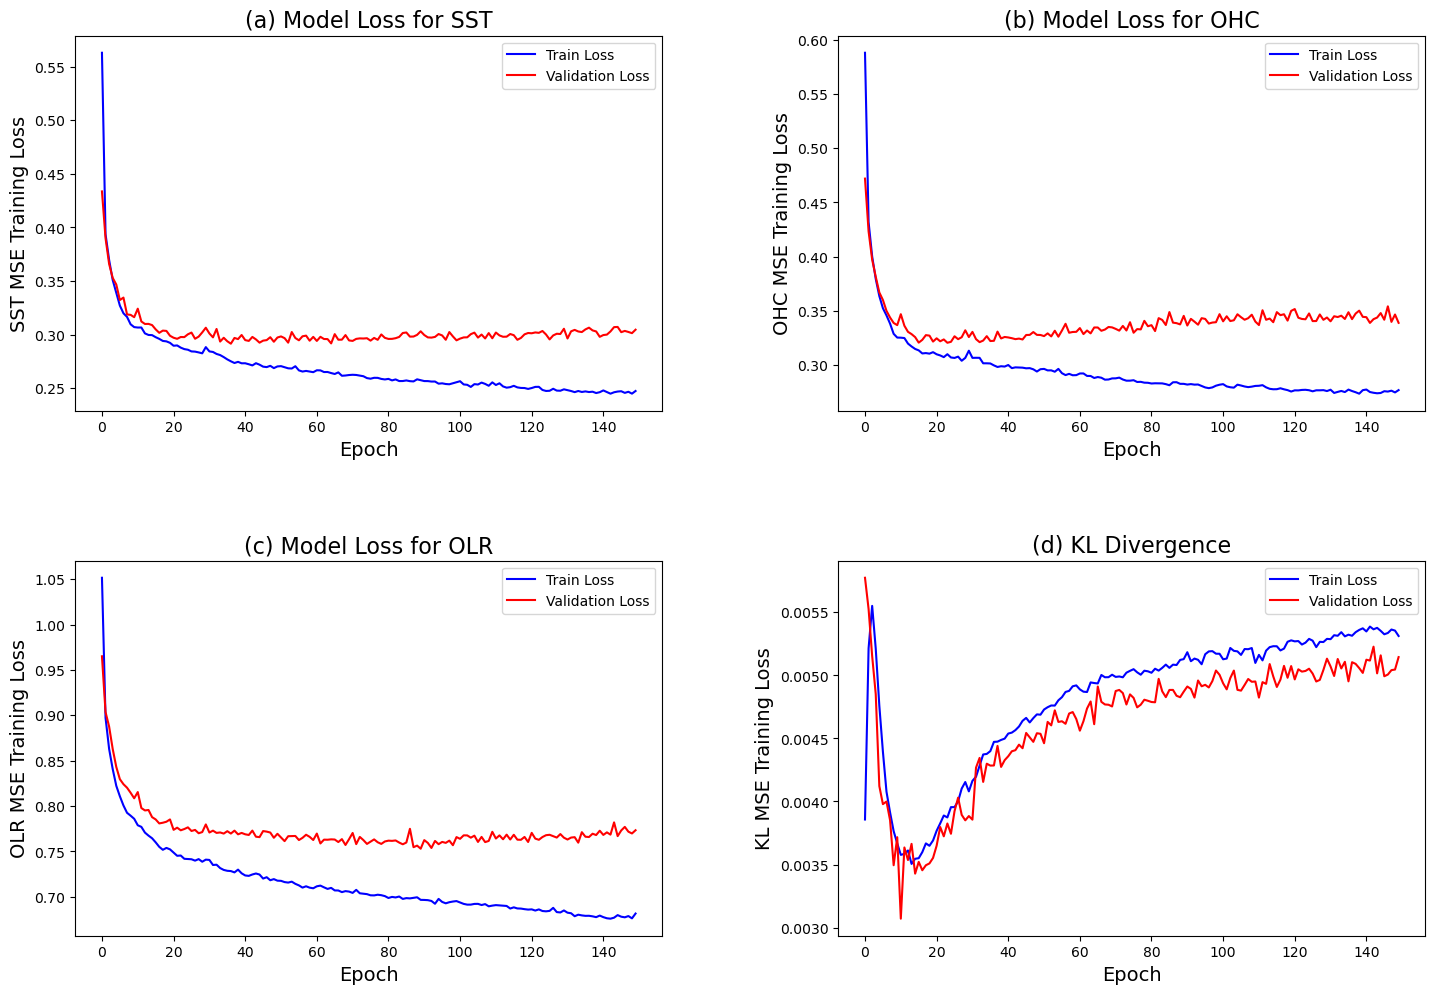

In [111]:
# Create a 4x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.95, wspace=0.30, hspace=0.4)

# Flatten the axes array for easier indexing
axes = axes.flatten()

# Plot for SST Loss
axes[0].set_title('(a) Model Loss for SST', fontsize=16)
axes[0].set_xlabel('Epoch', fontsize=14)
axes[0].set_ylabel('SST MSE Training Loss', fontsize=14)
axes[0].plot(vae_model_history.history['sst_loss'], color='blue', label='Train Loss')
axes[0].plot(vae_model_history.history['val_sst_loss'], color='red', label='Validation Loss')
axes[0].legend(loc='best')

# Plot for OHC Loss
axes[1].set_title('(b) Model Loss for OHC', fontsize=16)
axes[1].set_xlabel('Epoch', fontsize=14)
axes[1].set_ylabel('OHC MSE Training Loss', fontsize=14)
axes[1].plot(vae_model_history.history['ohc_loss'], color='blue', label='Train Loss')
axes[1].plot(vae_model_history.history['val_ohc_loss'], color='red', label='Validation Loss')
axes[1].legend(loc='best')

# Plot for OLR Loss
axes[2].set_title('(c) Model Loss for OLR', fontsize=16)
axes[2].set_xlabel('Epoch', fontsize=14)
axes[2].set_ylabel('OLR MSE Training Loss', fontsize=14)
axes[2].plot(vae_model_history.history['olr_loss'], color='blue', label='Train Loss')
axes[2].plot(vae_model_history.history['val_olr_loss'], color='red', label='Validation Loss')
axes[2].legend(loc='best')

# Plot for KL Loss
axes[3].set_title('(d) KL Divergence', fontsize=16)
axes[3].set_xlabel('Epoch', fontsize=14)
axes[3].set_ylabel('KL MSE Training Loss', fontsize=14)
axes[3].plot(vae_model_history.history['kl_loss'], color='blue', label='Train Loss')
axes[3].plot(vae_model_history.history['val_kl_loss'], color='red', label='Validation Loss')
axes[3].legend(loc='best')

# Uncomment and adjust if you want to save the figure
# fig.suptitle('Adam, 150 Epochs, 256 Batch Size, 0.3 Validation Split', fontsize=20, y=1.02)
# plt.savefig('trainingloss.pdf', bbox_inches='tight')
plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/reconstructions/vae_allthreeinputs_losscurve_2latentdim.png', dpi=450, bbox_inches='tight', pad_inches=0.1)
plt.show()

## reconstructions

In [114]:
reconstructed_outputs = vae.predict(
    [sequential_input_sst_train, sequential_input_ohc_train, sequential_input_olr_train]
)

150/150 [==============================] - 5s 32ms/step


In [115]:
reconstructed_sst = reconstructed_outputs[0]
reconstructed_ohc = reconstructed_outputs[1]
reconstructed_olr = reconstructed_outputs[2]

In [116]:
print(reconstructed_sst.shape,
      reconstructed_ohc.shape,
      reconstructed_olr.shape)

(4800, 2968) (4800, 2960) (4800, 2662)


In [117]:
reconstructed_sst

array([[-0.08060479, -0.08119862, -0.0582152 , ..., -0.29349008,
        -0.29211915, -0.2887323 ],
       [ 0.79881525,  0.79453444,  0.7794728 , ...,  0.02443129,
         0.05669739, -0.01981746],
       [-0.17126857, -0.191778  , -0.17892161, ...,  0.00489403,
        -0.01832242,  0.01207885],
       ...,
       [-0.0364144 ,  0.01240113, -0.03423627, ...,  0.06964565,
         0.05567274,  0.05996289],
       [-0.21347006, -0.24413627, -0.2277561 , ...,  0.08713049,
         0.06424013,  0.09689786],
       [-0.5421269 , -0.5906475 , -0.55408525, ...,  0.35220677,
         0.32671937,  0.37926835]], dtype=float32)

In [118]:
reconstructed_ohc

array([[-0.0580546 , -0.03480648, -0.02570098, ..., -0.02190078,
        -0.04502457, -0.06005906],
       [ 0.5905785 ,  0.6399879 ,  0.6631066 , ..., -0.09200639,
        -0.03383779,  0.01079924],
       [-0.22203206, -0.23500636, -0.23654969, ...,  0.14264008,
         0.10537384,  0.10164833],
       ...,
       [ 0.11191785,  0.04965474,  0.00962649, ..., -0.03431888,
        -0.04935758, -0.06082439],
       [-0.30286562, -0.30632904, -0.3123884 , ...,  0.13125663,
         0.09292571,  0.09334417],
       [-0.58412224, -0.5878253 , -0.60436827, ...,  0.05448712,
         0.00247535,  0.00890011]], dtype=float32)

In [119]:
reconstructed_olr

array([[-0.10036653, -0.06342409, -0.08019605, ..., -0.02898982,
        -0.07771298, -0.09809801],
       [-0.11831735, -0.05892218, -0.03806542, ..., -0.4261787 ,
        -0.44263288, -0.48086897],
       [-0.15131044, -0.15981962, -0.23506437, ..., -0.02256159,
        -0.0223882 , -0.03599738],
       ...,
       [ 0.00364532,  0.00871145, -0.10460792, ..., -0.00666255,
        -0.01489868,  0.1038571 ],
       [-0.03031883, -0.03973315, -0.13816178, ..., -0.11134302,
        -0.10733221, -0.07204637],
       [ 0.13497606,  0.06901362,  0.12837473, ...,  0.21196792,
         0.27007985,  0.30356762]], dtype=float32)

In [120]:
from sklearn.metrics import mean_squared_error

mse_sst = mean_squared_error(scaled_input_sst_train.flatten(), reconstructed_sst.flatten())
mse_ohc = mean_squared_error(scaled_input_ohc_train.flatten(), reconstructed_ohc.flatten())
mse_olr = mean_squared_error(scaled_input_olr_train.flatten(), reconstructed_olr.flatten())

In [121]:
print(mse_sst,
      mse_ohc,
      mse_olr
     )

0.2609722895905993 0.2915115139316529 0.7028502840680884


In [122]:
from sklearn.metrics import mean_absolute_error

mae_sst = mean_absolute_error(scaled_input_sst_train.flatten(), reconstructed_sst.flatten())
mae_ohc = mean_absolute_error(scaled_input_ohc_train.flatten(), reconstructed_ohc.flatten())
mae_olr = mean_absolute_error(scaled_input_olr_train.flatten(), reconstructed_olr.flatten())

In [123]:
print(mae_sst,
      mae_ohc,
      mae_olr
     )

0.3879646132223555 0.4167101579501135 0.6056185859793028


In [124]:
from sklearn.metrics import r2_score

r2_sst = r2_score(scaled_input_sst_train.flatten(), reconstructed_sst.flatten())
r2_ohc = r2_score(scaled_input_ohc_train.flatten(), reconstructed_ohc.flatten())
r2_olr = r2_score(scaled_input_olr_train.flatten(), reconstructed_olr.flatten())

In [125]:
print(r2_sst,
      r2_ohc,
      r2_olr
     )

0.5952127105176971 0.5571714950906848 0.36811323605831336


In [126]:
# indices can be loaded anytime and used for reconstruction
sst_yindx = np.load('sst_yindx.npy')
sst_xindx = np.load('sst_xindx.npy')

def reconstruct_grid(pred_1d, y_indx, x_indx):
    """
    Reconstruct the original 2d grid using NN predictions.
    Args:
        pred_1d (xarray data array): predictions (samples, 1d values)
        y_indx (numpy array): latitude indices for grid (20)
        x_indx (numpy array): longitude indices for grid (150)
    Returns:
        pred_grid (numpy array): predictions on original 2d grid
    """
    # number of predicted samples (!assuming axis=0!)
    n_samples = pred_1d.shape[0]
    
    # grid to be populated with predicted data
    pred_grid = np.full((n_samples, 20, 150), np.nan)
    
    # fill the reconstructed grid
    pred_grid[:, y_indx, x_indx] = pred_1d#.values
    
    # return predictions on original 2d grid
    return pred_grid

In [127]:
# import scaler to get physical ohc values
scaler_sst = joblib.load('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/data/scaler_sst.pkl')

# Step 1: Undo the scaling (inverse transformation)
flattened_reconstructed_sst = reconstructed_sst.reshape(len(reconstructed_sst), -1)  # Flatten the data for inverse scaling
sst_reconstructed_physical = scaler_sst.inverse_transform(flattened_reconstructed_sst)

# Step 1: Undo the scaling (inverse transformation)
flattened_input_sst = scaled_input_sst_train.reshape(len(scaled_input_sst_train), -1)  # Flatten the data for inverse scaling
sst_input_physical = scaler_sst.inverse_transform(flattened_input_sst) 

In [128]:
print(scaled_input_sst_train.shape,
      reconstructed_sst.shape,
      sst_reconstructed_physical.shape,
      sst_input_physical.shape
     )

(4800, 2968) (4800, 2968) (4800, 2968) (4800, 2968)


In [129]:
# Reconstruct original input SST and predicted SST
sst_input_reconstructed = reconstruct_grid(sst_input_physical, sst_yindx, sst_xindx)
sst_output_reconstructed = reconstruct_grid(sst_reconstructed_physical, sst_yindx, sst_xindx)

In [130]:
sst_input_reconstructed.shape

(4800, 20, 150)

In [131]:
sst_output_reconstructed.shape

(4800, 20, 150)

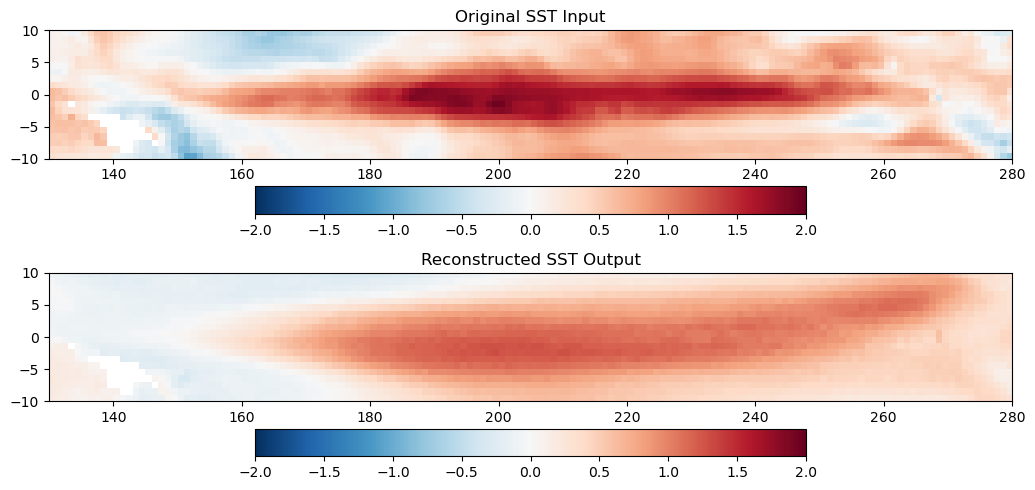

In [132]:
import matplotlib.pyplot as plt
#43

sample = 137 # choose the time step you want to visualize

fig, axs = plt.subplots(2, 1, figsize=(12, 5))

# Define latitude and longitude ranges
lat_bounds = (-10, 10)
lon_bounds = (130, 280)

# Original input
im0 = axs[0].imshow(sst_input_reconstructed[sample], cmap='RdBu_r', vmin=-2, vmax=2, origin='lower',
                   extent=[lon_bounds[0], lon_bounds[1], lat_bounds[0], lat_bounds[1]])
axs[0].set_title('Original SST Input')
fig.colorbar(im0, ax=axs[0], orientation='horizontal')

# Reconstructed output
im1 = axs[1].imshow(sst_output_reconstructed[sample], cmap='RdBu_r', vmin=-2, vmax=2, origin='lower',
                   extent=[lon_bounds[0], lon_bounds[1], lat_bounds[0], lat_bounds[1]])
axs[1].set_title('Reconstructed SST Output')
fig.colorbar(im1, ax=axs[1], orientation='horizontal')

plt.tight_layout()
plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/reconstructions/vae_allthreeinputs_spatial_2latentdim.png', dpi=450, bbox_inches='tight', pad_inches=0.1)
plt.show()

## Extract latent space using sequential data

In [ ]:
# Concatenate the train and test datasets along the 'time' dimension
ohc_combined = xr.concat([sequential_input_ohc_train, sequential_input_ohc_test], dim='time')
olr_combined = xr.concat([sequential_input_olr_train, sequential_input_olr_test], dim='time')
sst_combined = xr.concat([sequential_input_sst_train, sequential_input_sst_test], dim='time')

In [ ]:
ohc_sequential = ohc_combined.sortby('time')
olr_sequential = olr_combined.sortby('time')
sst_sequential = sst_combined.sortby('time')

In [ ]:
ohc_train = ohc_sequential.sel(time=slice('0001-01-01', '0400-12-01'))
ohc_test = ohc_sequential.sel(time=slice('0401-01-01', '0500-12-01'))
olr_train = olr_sequential.sel(time=slice('0001-01-01', '0400-12-01'))
olr_test = olr_sequential.sel(time=slice('0401-01-01', '0500-12-01'))
sst_train = sst_sequential.sel(time=slice('0001-01-01', '0400-12-01'))
sst_test = sst_sequential.sel(time=slice('0401-01-01', '0500-12-01'))

In [ ]:
sst_sequential

In [ ]:
ohc_sequential

In [ ]:
olr_sequential

## create latent representations of the data

In [ ]:
from tensorflow.keras.models import Model

# Create an encoder model that stops at the `z_sampling` layer
encoder_model = Model(inputs=[input_sst, input_ohc, input_olr],
                      outputs=vae.get_layer('z_sampling').output)

# Use this encoder model to get the latent space representations from your data
# Replace `sst_data`, `ohc_data`, and `olr_data` with your actual input data arrays
keras.utils.set_random_seed(1)
latent_representations = (encoder_model.predict([sst_sequential, ohc_sequential, olr_sequential]))

# check shapes
print(latent_representations.shape, latent_representations[:,0].shape)

In [ ]:
# function to create custom dates
def generate_custom_dates(start_year, start_month, periods):
    dates = []
    year, month = start_year, start_month
    for _ in range(periods):
        dates.append(f'{year:04d}-{month:02d}-01')
        month += 1
        if month > 12:
            month = 1
            year += 1
    return dates

# string representations of dates
vae_model_index = pd.DataFrame(latent_representations)
dates = generate_custom_dates(start_year=1, start_month=1, periods=len(vae_model_index))
vae_model_index['date'] = dates
date = vae_model_index['date']

# check
print(vae_model_index)

In [ ]:
type(vae_model_index)

In [ ]:
# mean 
mean = vae_model_index[0].values
print(mean.shape)

var_test = vae_model_index[1].values # log(sigma_squared)
print(var_test.shape)

#std_dev = np.sqrt(np.exp(log_variance))
std_dev = np.sqrt(np.exp(var_test))
print(std_dev.shape)

# sigma and std dev should be the same
sigma = np.exp(var_test / 2)
print(sigma.shape)

# compute upper and lower/upper bounds 
upper_bound = mean + sigma
lower_bound = mean - sigma

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(vae_model_index['date'], mean, color='black', label='Mean')
plt.fill_between(vae_model_index['date'], lower_bound, upper_bound, color='green', alpha=0.5, label='Uncertainty (±σ)')
#plt.xticks(vae_model_index['date'][::235], rotation=45)
plt.xticks(vae_model_index['date'][::10], rotation=45)
plt.xlim(['0001-01-01', '0012-01-01'])
plt.title('Latent Space with Uncertainty')
plt.ylabel('Latent Space Value')
plt.xlabel('Time')
plt.ylim(-6, 6)
plt.legend()
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/agufigs/vae_uncertainty_v3.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

## add oni

In [ ]:
oni_e3sm = genfromtxt('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/scaleddata/oni_e3sm.csv', delimiter=',')
print(oni_e3sm, oni_e3sm.shape)

In [ ]:
# use function again to create dates in weird climate model land
def generate_custom_dates(start_year, start_month, periods):
    dates = []
    year, month = start_year, start_month
    for _ in range(periods):
        dates.append(f'{year:04d}-{month:02d}-01')
        month += 1
        if month > 12:
            month = 1
            year += 1
    return dates

# create string representations of dates
oni_dates = pd.DataFrame(oni_e3sm)
train_dates = generate_custom_dates(start_year=1, start_month=1, periods=len(oni_dates))
oni_dates['date'] = train_dates
date = oni_dates['date']

# check to see if working correctly
print(oni_dates)

In [ ]:
# add oni to previous figure

plt.figure(figsize=(12,4))
plt.plot(vae_model_index['date'], mean, color='black', label='Mean from Index')
plt.plot(oni_dates['date'], oni_dates[0], label='ONI in E3SM', color='red', linestyle='--')
plt.fill_between(vae_model_index['date'], lower_bound, upper_bound, color='green', alpha=0.25, label='Uncertainty (±σ)')
#plt.xticks(vae_model_index['date'][::235], rotation=45)
plt.xticks(vae_model_index['date'][::20], rotation=45)
plt.xlim(['0250-01-01', '0270-01-01'])
plt.title('VAE Model Index')
plt.ylabel(r'Uncertainty ($\sigma$)')
plt.xlabel('Time')
plt.ylim(-5, 6)
plt.legend(fontsize=7.5, loc='upper right')
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/hawaii/vaeindex_uncertainty_0306.pdf', bbox_inches='tight', pad_inches=0.1)
plt.show()

## sst sequential DJF (for pca and correlation maps later)

In [46]:
sst_sequential

<xarray.DataArray (time: 6000, newdim: 2968)> Size: 71MB
array([[-0.5002564 , -0.3324281 , -0.30272764, ..., -0.73566824,
        -0.7658717 , -0.89404434],
       [-0.16353978, -0.21187238, -0.20433865, ..., -0.28456235,
        -0.21834068, -0.26097935],
       [ 0.16477168,  0.14165063,  0.11321359, ..., -0.4561735 ,
        -0.33967522, -0.19781172],
       ...,
       [ 1.7001326 ,  1.6598228 ,  1.6910105 , ...,  0.34886822,
         0.39041856,  0.3548891 ],
       [ 1.2735761 ,  1.3094018 ,  1.3412584 , ..., -0.46923903,
        -0.42496276, -0.36724132],
       [-0.12548369, -0.09509756, -0.0847574 , ..., -0.69052964,
        -0.8497298 , -0.80991197]], dtype=float32)
Coordinates:
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24kB 130.5 131.5 132.5 133.5 ... 277.5 278.5 279.5
Dimensions without coordinates: newdim

In [47]:
# create 3 month rolling mean (centered)
sst_rolling_mean = sst_sequential.rolling(time=3, center=True).mean()
print(sst_rolling_mean.shape)

# center in january and drop rest of points
djf_means = sst_rolling_mean.where(sst_sequential["month"] == 1, drop=True)
print(djf_means.shape)

# drop first time step due to NaN values
djf_means = djf_means[1:,] 
print(djf_means.shape)
print(djf_means)

(6000, 2968)
(500, 2968)
(499, 2968)
<xarray.DataArray (time: 499, newdim: 2968)> Size: 6MB
array([[-0.5581535 , -0.52172387, -0.48049757, ..., -0.60934347,
        -0.55603087, -0.43565345],
       [ 0.27001506,  0.20396142,  0.13423255, ...,  0.697432  ,
         0.76590437,  0.8100104 ],
       [-0.38038465, -0.26910478, -0.10929748, ...,  0.0295077 ,
        -0.0068664 , -0.03569696],
       ...,
       [-0.30227873, -0.26245213, -0.24800353, ..., -0.1921622 ,
        -0.19559622, -0.20234536],
       [ 0.3766086 ,  0.3617643 ,  0.30372167, ...,  0.2284622 ,
         0.26242423,  0.24034423],
       [ 0.16016579,  0.07801533,  0.07721727, ...,  0.29234472,
         0.2538977 ,  0.26496226]], dtype=float32)
Coordinates:
  * time     (time) object 4kB 0002-01-01 00:00:00 ... 0500-01-01 00:00:00
    month    (time) int64 4kB 1 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1 1
    lat      (newdim) float64 24kB -9.5 -9.5 -9.5 -9.5 -9.5 ... 9.5 9.5 9.5 9.5
    lon      (newdim) float64 24

In [48]:
# pca of djf_means 
pca_sst_only = PCA(n_components = 2)
sst_pca_components = pca_sst_only.fit_transform(djf_means)
# shape should be (499, 2)
print(sst_pca_components.shape)

# print min and max for scaling purposes
print(sst_pca_components.min(), sst_pca_components.max())

(499, 2)
-98.41606 99.721596


In [49]:
# scale for later usage 
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

# Ensure we are scaling only 1D arrays (not accidentally stacking multiple PC1s)
pc1_sstonly_scaled = scaler.fit_transform(sst_pca_components[:, 0].reshape(-1, 1)).flatten()
print(pc1_sstonly_scaled.shape)
print(pc1_sstonly_scaled.min(), pc1_sstonly_scaled.max(), pc1_sstonly_scaled.mean(), pc1_sstonly_scaled.std())

# use pc1_sstonly_scaled for teleconnections maps comparing reference temperature and VAE!
# this will give us information on the DJF PCA for one variable (global)

(499,)
-1.9926502 2.0743647 0.027458388 0.7753501


### oni from E3SM (for pca and teleconnection maps later on)

In [50]:
# Stack the original input variables
#original_data = np.hstack([sst_sequential, ohc_sequential, olr_sequential])

# already computed rolling mean in previous notebook
# for DJF, extract month of january and drop everything else

# Extract month as integer from the string (characters 6 and 7)
months = oni_dates['date'].str[5:7].astype(int)

# Create mask for January
january_mask = months == 1

# Apply mask to get DJF means (centered on January)
oni_djf = oni_dates[january_mask]

# should now be (500, 2)
print(oni_djf.shape)
print(oni_djf)

# remove first time step (incomplete djf)
oni_djf = oni_djf[1:]
print(oni_djf)
print(oni_djf.shape)

(500, 2)
             0        date
0          NaN  0001-01-01
12   -0.911187  0002-01-01
24    1.326085  0003-01-01
36   -1.425254  0004-01-01
48   -0.222566  0005-01-01
...        ...         ...
5940  0.144753  0496-01-01
5952  0.276979  0497-01-01
5964  0.526154  0498-01-01
5976 -0.092400  0499-01-01
5988  3.461168  0500-01-01

[500 rows x 2 columns]
             0        date
12   -0.911187  0002-01-01
24    1.326085  0003-01-01
36   -1.425254  0004-01-01
48   -0.222566  0005-01-01
60    1.486306  0006-01-01
...        ...         ...
5940  0.144753  0496-01-01
5952  0.276979  0497-01-01
5964  0.526154  0498-01-01
5976 -0.092400  0499-01-01
5988  3.461168  0500-01-01

[499 rows x 2 columns]
(499, 2)


In [51]:
# pca on E3SM ONI (DJF)
pca_e3sm_oni = PCA(n_components = 1)
oni_pca_components = pca_e3sm_oni.fit_transform(oni_djf[0].values.reshape(-1, 1))
#print(oni_pca_components)
print(oni_pca_components.min(), oni_pca_components.max(), oni_pca_components.mean(), oni_pca_components.std())

# scale 
scaler_oni = RobustScaler()
oni_pca_scaled = scaler_oni.fit_transform(oni_pca_components).flatten()
print(oni_pca_scaled.shape)
print(oni_pca_scaled.min(), oni_pca_scaled.max(), oni_pca_scaled.mean(), oni_pca_scaled.std())
print(oni_pca_scaled.shape)

-2.7230596253648978 3.4586715986951604 -1.4239333381965934e-17 1.0912680535371493
(499,)
-1.8969036780349866 2.53964651177733 0.057401719579551036 0.7831892579238608
(499,)


### reference temperature from picontrol (for teleconnections)

In [52]:
def help_adding_year(yr):
    """
    Update year string by adding one and return string.
    Args:
        yr (str): year
    """
    assert len(yr) == 4, 'year string is not correct length!'
    newyr = int(yr) + 1
    newyr = str(newyr)
    newyr = newyr.zfill(4)
    return newyr


def convert_mo_str(mo):
    """
    Convert integer month to two-digit month string.
    Args:
        mo (int): month
    """
    assert type(mo) is int, 'not an integer'
    return str(mo).zfill(2)


def help_updating_time(mo, yr):
    """
    Updating the month and year in cftime due to february start in cesm.
    Year and month (if december) are fixed.
    Args:
        mo (str): xarray filename
        yr (str): xarray filename
    """
    newmo = int(mo) + 1
    if newmo == 13:
        yr = help_adding_year(yr)
        newmo = 1
    assert newmo <= 12, 'month is greater than 12, there is an error!'
    newmo = convert_mo_str(newmo)
    return newmo, yr


def fixtime(ds):
    """
    Open file and add time coordinate.
    Args:
        ds (xarray dataset)
    """
    # start date range preprocessing
    mo0 = ds.encoding['source'].split('/')[-1].split('.')[-2][4:6]
    yr0 = ds.encoding['source'].split('/')[-1].split('.')[-2][:4]
    nm0, ny0 = help_updating_time(mo0, yr0)
    # end date range preprocessing
    yr1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-6:-2]
    mo1 = ds.encoding['source'].split('/')[-1].split('.')[-2][-2:]
    nm1, ny1 = help_updating_time(mo1, yr1)
    # create datetime array in cftime
    newtime = xr.cftime_range(
        start=ny0+'-'+nm0+'-01',
        end=ny1+'-'+nm1+'-01',
        freq='MS',
        calendar='noleap'
    )
    ds = ds.assign_coords(time=newtime)
    return ds

In [53]:
temp_2m = xr.open_mfdataset(
    '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/v2.FV1.piControl/atm/proc/tseries/month_1/v2.FV1.piControl.eam.h0.TREFHT.*.nc',
    preprocess=fixtime,
    concat_dim='time',
    combine='nested'
)

In [54]:
temp_2m

<xarray.Dataset> Size: 4GB
Dimensions:              (time: 6000, lat: 192, nbnd: 2, lon: 288, cosp_ht: 40,
                          cosp_htmisr: 16, cosp_prs: 7, cosp_reffice: 6,
                          cosp_reffliq: 6, cosp_sr: 15, cosp_tau: 7,
                          cosp_tau_modis: 7, ilev: 73, lev: 72, cosp_scol: 10,
                          cosp_sza: 5)
Coordinates: (12/15)
  * lat                  (lat) float64 2kB -90.0 -89.06 -88.12 ... 89.06 90.0
  * lon                  (lon) float64 2kB 0.0 1.25 2.5 ... 356.2 357.5 358.8
  * cosp_ht              (cosp_ht) float64 320B 1.896e+04 1.848e+04 ... 240.0
  * cosp_htmisr          (cosp_htmisr) float64 128B 0.0 250.0 ... 1.8e+04
  * cosp_prs             (cosp_prs) float64 56B 9e+04 7.4e+04 ... 2.45e+04 9e+03
  * cosp_reffice         (cosp_reffice) float64 48B 5e-06 1.5e-05 ... 7.5e-05
    ...                   ...
  * cosp_sza             (cosp_sza) float64 40B 0.0 20.0 40.0 60.0 80.0
  * cosp_tau             (cosp_tau) float64 56B 0.15 0.8 2.45 ... 41.5 100.0
  * cosp_tau_modis       (cosp_tau_modis) float64 56B 0.15 0.8 ... 41.5 100.0
  * ilev                 (ilev) float64 584B 0.1 0.1477 0.218 ... 997.0 1e+03
  * lev                  (lev) float64 576B 0.1238 0.1828 0.2699 ... 993.8 998.5
  * time                 (time) object 48kB 0001-02-01 00:00:00 ... 0501-01-0...
Dimensions without coordinates: nbnd
Data variables: (12/37)
    lat_bnds             (time, lat, nbnd) float64 18MB dask.array<chunksize=(1200, 192, 2), meta=np.ndarray>
    lon_bnds             (time, lon, nbnd) float64 28MB dask.array<chunksize=(1200, 288, 2), meta=np.ndarray>
    gw                   (time, lat) float64 9MB dask.array<chunksize=(1200, 192), meta=np.ndarray>
    area                 (time, lat, lon) float64 3GB dask.array<chunksize=(1200, 192, 288), meta=np.ndarray>
    P0                   (time) float64 48kB 1e+05 1e+05 1e+05 ... 1e+05 1e+05
    cosp_ht_bnds         (time, cosp_ht, nbnd) float64 4MB dask.array<chunksize=(1200, 40, 2), meta=np.ndarray>
    ...                   ...
    nscur                (time) int32 24kB dask.array<chunksize=(1024,), meta=np.ndarray>
    nsteph               (time) int32 24kB dask.array<chunksize=(1024,), meta=np.ndarray>
    sol_tsi              (time) float64 48kB dask.array<chunksize=(512,), meta=np.ndarray>
    time_bnds            (time, nbnd) object 96kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_written         (time) |S8 48kB dask.array<chunksize=(1,), meta=np.ndarray>
    TREFHT               (time, lat, lon) float32 1GB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
Attributes: (12/26)
    ne:                        30
    fv_nphys:                  2
    title:                     EAM History file information
    source:                    E3SM Atmosphere Model
    source_id:                 96c3ee8f6d
    product:                   model-output
    ...                        ...
    remap_hostname:            nid006377
    remap_version:             5.0.1
    NCO:                       netCDF Operators version 5.0.1 (Homepage = htt...
    nco_openmp_thread_number:  2
    map_file:                  /global/u2/s/strandwg/proj/proc/2E3SM/map_ne30...
    input_file:                /pscratch/sd/s/strandwg/E3SMv2/v2.LR.piControl...

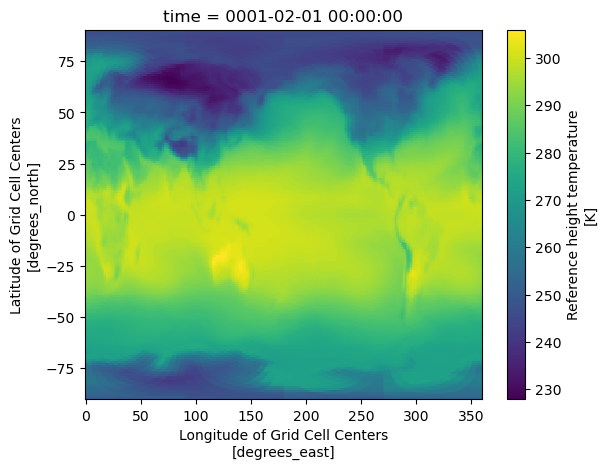

In [55]:
temp_2m['TREFHT'].isel(time=0).plot()

### compute anomalies

/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/xarray/core/indexing.py:1621: PerformanceWarning: Slicing with an out-of-order index is generating 500 times more chunks
  return self.array[key]


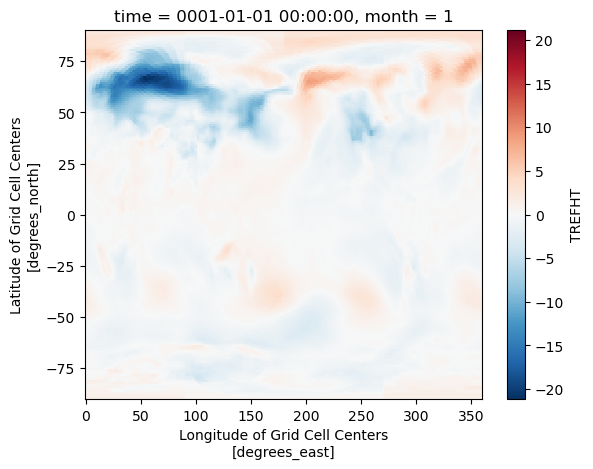

In [49]:
# compute anomalies from climatology
temp_2m = temp_2m['TREFHT']

# fix start time of model to january instead of february
temp_2m = temp_2m.assign_coords(time=temp_2m['time'] - 
                                        xr.coding.cftime_offsets.MonthBegin(1))

# climo
climatology = temp_2m.groupby('time.month').mean(dim='time', keep_attrs=True)

# anomalies
anomalies = temp_2m.groupby('time.month') - climatology

# test anomalies by plotting quick map
anomalies.isel(time=0).plot()
plt.show()

In [51]:
# djf
anomalies_rolling_mean = anomalies.rolling(time=3, center=True).mean()

In [52]:
anomalies_rolling_mean

<xarray.DataArray 'TREFHT' (time: 6000, lat: 192, lon: 288)> Size: 1GB
dask.array<truediv, shape=(6000, 192, 288), dtype=float32, chunksize=(3, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 48kB 0001-01-01 00:00:00 ... 0500-12-01 00:00:00
    month    (time) int64 48kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

In [54]:
anomalies_djf = anomalies_rolling_mean.where(anomalies_rolling_mean["month"] == 1, drop=True)
print(anomalies_djf.shape)

(500, 192, 288)


In [61]:
temp2m_anomalies_djf = anomalies_djf[1:,]

In [63]:
temp2m_anomalies_djf 

<xarray.DataArray 'TREFHT' (time: 499, lat: 192, lon: 288)> Size: 110MB
dask.array<getitem, shape=(499, 192, 288), dtype=float32, chunksize=(1, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 4kB 0002-01-01 00:00:00 ... 0500-01-01 00:00:00
    month    (time) int64 4kB 1 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1 1

In [64]:
# manually compute DJF
# more complicated than necessary but this works right now!

# manually create a 'year' coordinate
#n_years = anomalies.sizes['time'] // 12
#year_full = np.repeat(np.arange(1, n_years + 1), 12)[:anomalies.sizes['time']]
#anomalies = anomalies.assign_coords(year=('time', year_full))

# compute DJF year (Dec counts as next year)
# assigning number to make grouping easier
# 0001-12-01 will be 2
# we will drop first year and last year
#djf_year = anomalies['year'] + (anomalies['month'] == 12)
#anomalies = anomalies.assign_coords(djf_year=('time', djf_year.data))

# quick check if needed 
#print(anomalies['djf_year'][:25])

# manually select only DJF months
#anomalies_djf = anomalies.where(anomalies['month'].isin([12, 1, 2]), drop=True)

# group by DJF year and take mean
#djf_anomalies = anomalies_djf.groupby('djf_year').mean(dim='time')
#print(djf_anomalies.shape)

# drop first and last data point
#djf_anom = djf_anomalies[1:,:]
#reference_t_djf = djf_anom[:-1,:]

# check shape
#print(reference_t_djf.shape)

### vae DJF (only mu for now)

In [66]:
type(vae_model_index)

pandas.core.frame.DataFrame

In [84]:
vae_model_index

,0,1,date
0,-0.725979,1.016992,0001-01-01
1,-0.285208,-0.171615,0001-02-01
2,-0.348177,0.175945,0001-03-01
3,0.341612,1.555284,0001-04-01
4,-0.260937,0.472691,0001-05-01
...,...,...,...
5995,-0.921800,-1.461198,0500-08-01
5996,-1.968615,-3.077145,0500-09-01
5997,-1.549204,-1.487036,0500-10-01
5998,-1.948327,0.071645,0500-11-01


In [68]:
vae_index = vae_model_index.to_xarray()

In [69]:
vae_index

<xarray.Dataset> Size: 144kB
Dimensions:  (index: 6000)
Coordinates:
  * index    (index) int64 48kB 0 1 2 3 4 5 6 ... 5994 5995 5996 5997 5998 5999
Data variables:
    0        (index) float32 24kB -0.726 -0.2852 -0.3482 ... -1.948 -1.827
    1        (index) float32 24kB 1.017 -0.1716 0.1759 ... -1.487 0.07164 0.1408
    date     (index) object 48kB '0001-01-01' '0001-02-01' ... '0500-12-01'

In [118]:
# convert to string and extract year/month
vae_model_index['date'] = vae_model_index['date'].astype(str)
vae_model_index['year'] = vae_model_index['date'].str[:4].astype(int)
vae_model_index['month'] = vae_model_index['date'].str[5:7].astype(int)

# assign DJF season to each row
# december will be added to following year
vae_model_index['djf_year'] = vae_model_index['year']
vae_model_index.loc[vae_model_index['month'] == 12, 'djf_year'] += 1

# filter for DJF months (12, 1, 2)
vae_djf = vae_model_index[vae_model_index['month'].isin([12, 1, 2])]

# sort by djf_year and month
vae_djf = vae_djf.sort_values(by=['djf_year', 'month'])

# check
print(vae_djf)

             0         1        date  year  month  djf_year
0    -0.689507  0.796495  0001-01-01     1      1         1
1    -0.557528 -0.174857  0001-02-01     1      2         1
12   -0.364266  0.654776  0002-01-01     2      1         2
13    0.217305  0.585973  0002-02-01     2      2         2
11   -1.068545  0.315109  0001-12-01     1     12         2
...        ...       ...         ...   ...    ...       ...
5975  0.490672  0.445962  0498-12-01   498     12       499
5988  3.848391 -1.561057  0500-01-01   500      1       500
5989  3.627237 -1.524708  0500-02-01   500      2       500
5987  3.776486  0.184312  0499-12-01   499     12       500
5999 -1.916640  0.244742  0500-12-01   500     12       501

[1500 rows x 6 columns]


In [120]:
# loop through each djf_year and compute 3-month rolling mean manually
djf_seasons = []
for year in vae_djf['djf_year'].unique():
    season_data = vae_djf[vae_djf['djf_year'] == year]
    if len(season_data) == 3:
        mean_0 = season_data[0].mean()
        mean_1 = season_data[1].mean()
        djf_seasons.append({
            'djf_year': year,
            'mean_0': mean_0,
            'mean_1': mean_1
        })

In [121]:
# has means for both mu and sigma
djf_seasons[:10]

[{'djf_year': 2, 'mean_0': -0.40516844, 'mean_1': 0.5186195},
 {'djf_year': 3, 'mean_0': 1.5567956, 'mean_1': 1.0089928},
 {'djf_year': 4, 'mean_0': -1.8474118, 'mean_1': 0.4504775},
 {'djf_year': 5, 'mean_0': -0.24838716, 'mean_1': 0.15139218},
 {'djf_year': 6, 'mean_0': 1.4894886, 'mean_1': -0.18574226},
 {'djf_year': 7, 'mean_0': 0.57206464, 'mean_1': -0.59706515},
 {'djf_year': 8, 'mean_0': -0.4482875, 'mean_1': 0.5142624},
 {'djf_year': 9, 'mean_0': 3.0645897, 'mean_1': -0.46799955},
 {'djf_year': 10, 'mean_0': -0.5808893, 'mean_1': 0.09837153},
 {'djf_year': 11, 'mean_0': 0.027785858, 'mean_1': -0.6707161}]

In [126]:
# Convert to DataFrame
vae_djf_rolling = pd.DataFrame(djf_seasons)
print(vae_djf_rolling)
print(vae_djf_rolling['mean_0'].values.shape)

     djf_year    mean_0    mean_1
0           2 -0.405168  0.518619
1           3  1.556796  1.008993
2           4 -1.847412  0.450478
3           5 -0.248387  0.151392
4           6  1.489489 -0.185742
..        ...       ...       ...
494       496  0.175318  1.105121
495       497  0.769938  0.082617
496       498  0.686795  0.674732
497       499 -0.223459  0.532833
498       500  3.750705 -0.967151

[499 rows x 3 columns]
(499,)


In [166]:
from scipy.stats import pearsonr

x = vae_djf_rolling['mean_0'].values
y = np.nanmean(reference_t_djf, axis=(1, 2))

r, p = pearsonr(x, y)
print(f"Pearson r = {r:.3f}, p-value = {p:.3g}")

from sklearn.linear_model import LinearRegression

x = x.reshape(-1, 1)  # shape (499, 1)
model = LinearRegression().fit(x, y)
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(x, y)

print(f"Slope = {slope:.3f}, Intercept = {intercept:.3f}, R² = {r2:.3f}")


KeyboardInterrupt



In [182]:
tmp = reference_t_djf.to_dataset().assign(
    vae_indx=(['djf_year'],
              vae_djf_rolling['mean_0'].values))

In [183]:
tmp

<xarray.Dataset> Size: 110MB
Dimensions:   (lat: 192, lon: 288, djf_year: 499)
Coordinates:
  * lat       (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon       (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * djf_year  (djf_year) int64 4kB 2 3 4 5 6 7 8 ... 494 495 496 497 498 499 500
Data variables:
    TREFHT    (djf_year, lat, lon) float32 110MB dask.array<chunksize=(1, 192, 288), meta=np.ndarray>
    vae_indx  (djf_year) float32 2kB -0.4052 1.557 -1.847 ... -0.2235 3.751

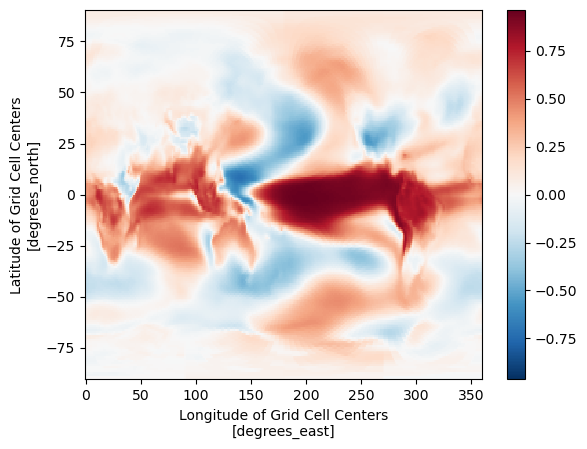

In [186]:
xr.corr(tmp.TREFHT, tmp.vae_indx, dim='djf_year')

In [191]:
tmp.TREFHT

<xarray.DataArray 'TREFHT' (djf_year: 499, lat: 192, lon: 288)> Size: 110MB
dask.array<getitem, shape=(499, 192, 288), dtype=float32, chunksize=(1, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon       (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * djf_year  (djf_year) int64 4kB 2 3 4 5 6 7 8 ... 494 495 496 497 498 499 500

In [134]:
x = oni_pca_scaled
y = np.nanmean(reference_t_djf, axis=(1, 2))

r, p = pearsonr(x, y)
print(f"Pearson r = {r:.3f}, p-value = {p:.3g}")

from sklearn.linear_model import LinearRegression

x = x.reshape(-1, 1)  # shape (499, 1)
model = LinearRegression().fit(x, y)
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(x, y)

print(f"Slope = {slope:.3f}, Intercept = {intercept:.3f}, R² = {r2:.3f}")

Pearson r = 0.352, p-value = 5.79e-16
Slope = 0.129, Intercept = -0.007, R² = 0.124


In [135]:
x = pc1_sstonly_scaled
y = np.nanmean(reference_t_djf, axis=(1, 2))

r, p = pearsonr(x, y)
print(f"Pearson r = {r:.3f}, p-value = {p:.3g}")

from sklearn.linear_model import LinearRegression

x = x.reshape(-1, 1)  # shape (499, 1)
model = LinearRegression().fit(x, y)
slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(x, y)

print(f"Slope = {slope:.3f}, Intercept = {intercept:.3f}, R² = {r2:.3f}")

Pearson r = 0.368, p-value = 2.09e-17
Slope = 0.136, Intercept = -0.003, R² = 0.135


In [137]:
np.nanmean(reference_t_djf, axis=(1, 2)).shape

(499,)

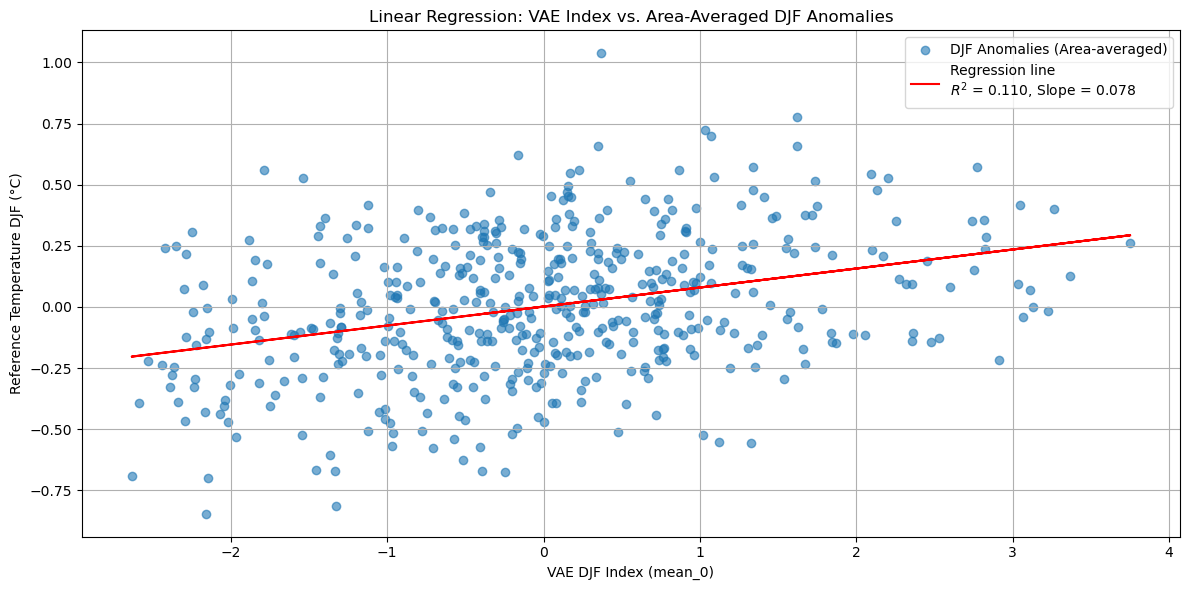

In [138]:
x = vae_djf_rolling['mean_0'].values.reshape(-1, 1)  # shape (499, 1)
y = np.nanmean(reference_t_djf, axis=(1, 2))          # shape (499,)

# Fit the model
model = LinearRegression().fit(x, y)
y_pred = model.predict(x)

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(x, y, label='DJF Anomalies (Area-averaged)', alpha=0.6)
plt.plot(x, y_pred, color='red', label=f'Regression line\n$R^2$ = {model.score(x, y):.3f}, Slope = {model.coef_[0]:.3f}')
plt.xlabel("VAE DJF Index (mean_0)")
plt.ylabel("Reference Temperature DJF (°C)")
plt.title("Linear Regression: VAE Index vs. Area-Averaged DJF Anomalies")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

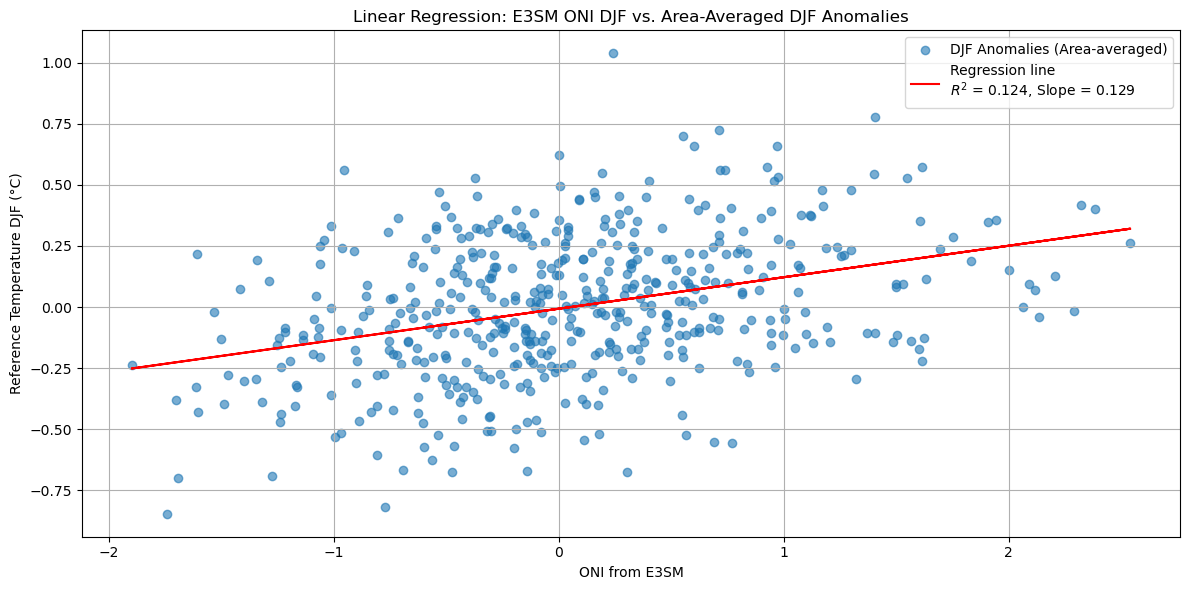

In [142]:
x = oni_pca_scaled.reshape(-1, 1)  # shape (499, 1)
y = np.nanmean(reference_t_djf, axis=(1, 2))          # shape (499,)

# Fit the model
model = LinearRegression().fit(x, y)
y_pred = model.predict(x)

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(x, y, label='DJF Anomalies (Area-averaged)', alpha=0.6)
plt.plot(x, y_pred, color='red', label=f'Regression line\n$R^2$ = {model.score(x, y):.3f}, Slope = {model.coef_[0]:.3f}')
plt.xlabel("ONI from E3SM")
plt.ylabel("Reference Temperature DJF (°C)")
plt.title("Linear Regression: E3SM ONI DJF vs. Area-Averaged DJF Anomalies")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### dask test

In [160]:
def get_ClusterClient():
    import dask
    from dask_jobqueue import PBSCluster
    from dask.distributed import Client
    cluster = PBSCluster(
        cores=1,
        memory='10GB',
        processes=1,
        queue='casper',
        resource_spec='select=1:ncpus=1:mem=10GB',
        account='UMCP0030',
        walltime='02:00:00')
        #interface='ib0',)

    dask.config.set({
        'distributed.dashboard.link':
        'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
    })
    client = Client(cluster)
    return cluster, client

In [161]:
cluster, client = get_ClusterClient()
#cluster.scale(20) 
cluster.adapt(minimum=0, maximum=20)

Task exception was never retrieved
future: <Task finished name='Task-591482' coro=<Client._gather.<locals>.wait() done, defined at /glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/distributed/client.py:2391> exception=AllExit()>
Traceback (most recent call last):
  File "/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/distributed/client.py", line 2400, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-591267' coro=<Client._gather.<locals>.wait() done, defined at /glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/distributed/client.py:2391> exception=AllExit()>
Traceback (most recent call last):
  File "/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/distributed/client.py", line 2400, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-591154' coro=<Client.

In [162]:
cluster

Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/ewisinski/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.118:36041,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/ewisinski/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [5]:
# Close out Dask Cluster and release workers:
# NOTE:  only run this cell to terminate Dask Cluster!
cluster.close()
client.close()

2025-04-09 18:36:48,010 - distributed.deploy.adaptive_core - INFO - Adaptive stop


### spatial maps!

/glade/derecho/scratch/ewisinski/tmp/ipykernel_8876/2168362585.py:21: RuntimeWarning: divide by zero encountered in divide
  corr_vae = numerator / (std_X * std_y) # shape (192*288,)


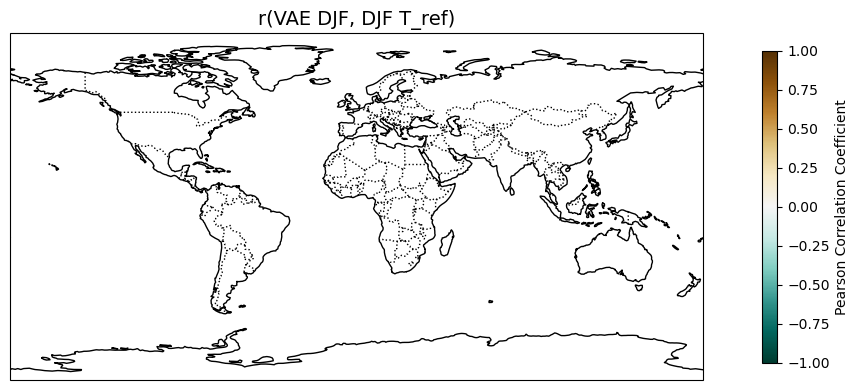

In [165]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# - djf_anomalies_centered of shape (499, 192, 288)
# - vae_djf_rolling['mean_0'].values  of shape (499,)

vae_djf = vae_djf_rolling['mean_0'].values

# Flatten lat/lon
djf_year, lat, lon = reference_t_djf.shape

X = reference_t_djf.values.reshape(499, 192 * 288)

# Compute correlation (numerator of Pearson r)
numerator = (X * vae_djf[:, None]).mean(axis=0)

# Compute denominator (std of each spatial time series * std of vae_mean)
std_X = X.std(axis=0)
std_y = vae_djf[0].std()

corr_vae = numerator / (std_X * std_y) # shape (192*288,)
#corr_map = corr.unstack("z")

# 1. If not already in 2D: reshape the flat corr into (lat, lon)
corr_2d_vae = corr_vae.reshape(lat, lon) if corr_vae.ndim == 1 else corr_vae

# 2. Create 2D lat/lon grid
lons, lats = np.meshgrid(reference_t_djf.lon, reference_t_djf.lat)

# 3. Plot with Cartopy
fig = plt.figure(figsize=(12, 4))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the data
pcm = ax.pcolormesh(lons, lats, corr_2d_vae, cmap='BrBG_r', vmin=-1, vmax=1, transform=ccrs.PlateCarree())

# Add features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_global()

# Colorbar and labels with adjusted size
cbar = plt.colorbar(pcm, orientation='vertical', ax=ax, shrink=0.9)
cbar.set_label('Pearson Correlation Coefficient')
plt.title('r(VAE DJF, DJF T_ref)', fontsize=14)
plt.tight_layout()
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/teleconnections/pearsonr_globalmap_vae.png', dpi=450, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [ ]:
# checks for oni 

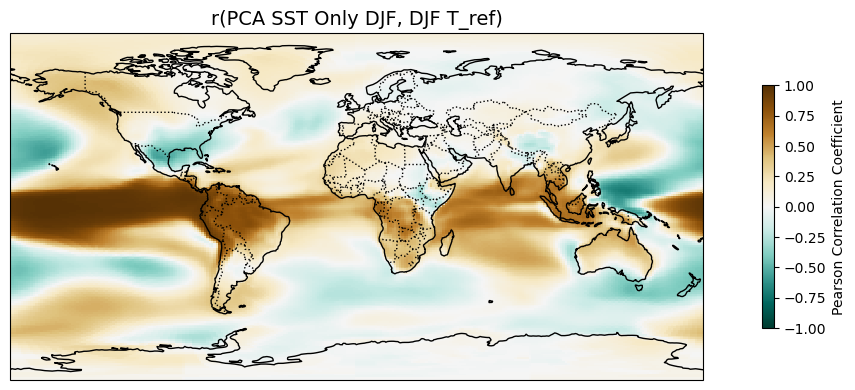

In [157]:
# - djf_anomalies_centered of shape (499, 192, 288)
# - vae_djf_rolling['mean_0'].values  of shape (499,)

oni = oni_pca_scaled  # standardized already

# Flatten lat/lon
djf_year, lat, lon = reference_t_djf.shape

X = reference_t_djf.values.reshape(499, 192 * 288)

# Compute correlation (numerator of Pearson r)
numerator = (X * oni[:, None]).mean(axis=0)

# Compute denominator (std of each spatial time series * std of vae_mean)
std_X = X.std(axis=0)
std_y = vae_djf[0].std()

corr_vae = numerator / (std_X * std_y) # shape (192*288,)
#corr_map = corr.unstack("z")

corr_sst = numerator / (std_X * std_y) # shape (192*288,)
#corr_map = corr.unstack("z") 

# 1. If not already in 2D: reshape the flat corr into (lat, lon)
corr_2d_sst = corr_sst.values.reshape(lat, lon) if corr_sst.ndim == 1 else corr_sst.values

# 2. Create 2D lat/lon grid
lons, lats = np.meshgrid(djf_anomalies.lon, djf_anomalies.lat)  # or from your dataset directly

# 3. Plot with Cartopy
fig = plt.figure(figsize=(12, 4))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the data
pcm = ax.pcolormesh(lons, lats, corr_2d_sst, cmap='BrBG_r', vmin=-1, vmax=1, transform=ccrs.PlateCarree())

# Add features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_global()

# Colorbar and labels with adjusted size
cbar = plt.colorbar(pcm, orientation='vertical', ax=ax, shrink=0.7)
cbar.set_label('Pearson Correlation Coefficient')

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title('r(PCA SST Only DJF, DJF T_ref)', fontsize=14)
plt.tight_layout()
#plt.imshow(corr_map, cmap='BrBG_r', vmin=-1, vmax=1)
#plt.colorbar(label='Correlation')
#plt.title('r(VAE DJF, DJF T_ref)')
#plt.xlabel('Longitude index')
#plt.ylabel('Latitude index')
#plt.tight_layout()
plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/teleconnections/pearsonr_globalmap_sstonly.png', dpi=450, bbox_inches='tight', pad_inches=0.1)
plt.show()

## linear regression

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Assuming vae_mean and djf_anomalies_centered are already defined
vae_mean = vae_djf.values  # standardized already

# Flatten lat/lon
djf_year, lat, lon = djf_anomalies_centered.shape

# Reshape the anomalies to 2D (djf_year, lat * lon)
X = djf_anomalies_centered.reshape(djf_year, lat * lon)

# Reshape vae_mean to (djf_year, lat * lon)
y = vae_mean

# Initialize the linear regression model
regressor = LinearRegression()

# Perform linear regression for all grid points at once
# Fit the model using all of X and y, and reshape it back to the lat, lon grid
regressor.fit(X, y)

# Get the coefficients (this is the regression coefficient for each spatial grid point)
regression_coefficients = regressor.coef_.reshape(lat, lon)

# Create a 2D lat/lon grid
lons, lats = np.meshgrid(djf_anomalies.lon, djf_anomalies.lat)  # or from your dataset directly

# Plot with Cartopy
fig = plt.figure(figsize=(12, 4))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the data
pcm = ax.pcolormesh(lons, lats, regression_coefficients, cmap='BrBG_r', vmin=-1, vmax=1, transform=ccrs.PlateCarree())

# Add features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_global()

# Colorbar and labels with adjusted size
cbar = plt.colorbar(pcm, orientation='vertical', ax=ax, shrink=0.7)
cbar.set_label('Linear Regression Coefficient')

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title('Linear Regression Coefficients (VAE DJF vs DJF T_ref)', fontsize=14)
plt.tight_layout()

plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/teleconnections/linearregression_globalmap_vae.png', dpi=450, bbox_inches='tight', pad_inches=0.1)
plt.show()


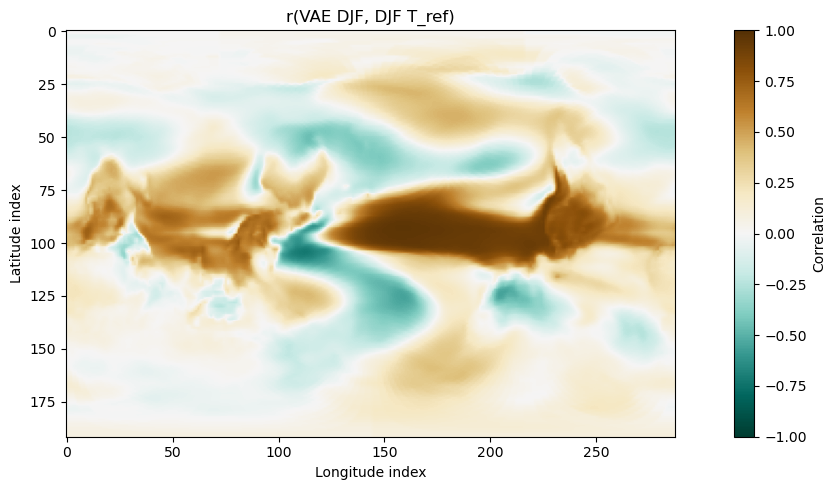

In [146]:
# - djf_anomalies_centered of shape (499, 192, 288)
# - vae_djf_rolling['mean_0'].values  of shape (499,)

vae_mean = vae_djf.values  # standardized already

# Flatten lat/lon
djf_year, lat, lon = djf_anomalies_centered.shape

# Compute correlation (numerator of Pearson r)
numerator = (X * vae_mean[:, None]).mean(axis=0)

# Compute denominator (std of each spatial time series * std of vae_mean)
std_X = X.std(axis=0)
std_y = vae_djf.std()

corr = numerator / (std_X * std_y) # shape (192*288,)
corr_map = corr.unstack("z") 

# Plotting
plt.figure(figsize=(12, 5))
plt.imshow(corr_map, cmap='BrBG_r', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title('r(VAE DJF, DJF T_ref)')
plt.xlabel('Longitude index')
plt.ylabel('Latitude index')
plt.tight_layout()
plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/teleconnections/pearsonr_globalmap_vae.png', dpi=450, bbox_inches='tight', pad_inches=0.1)
plt.show()

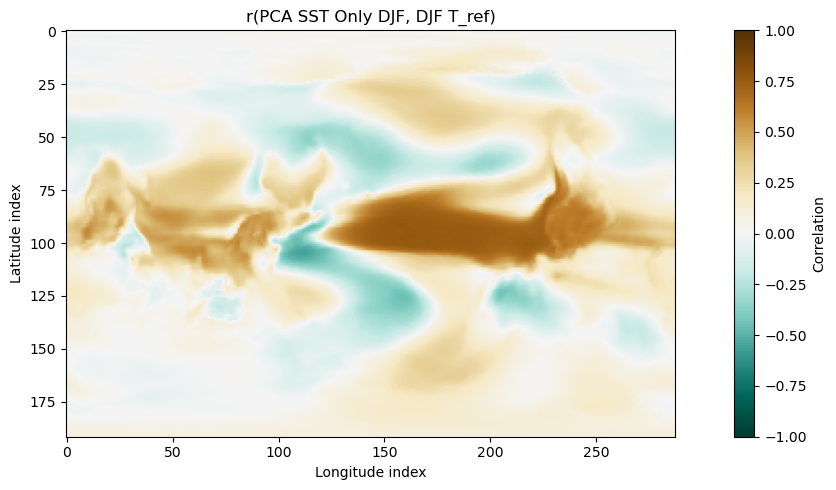

In [147]:
# Assume:
# - djf_anomalies is a Dask array of shape (499, 192, 288)
# - vae_djf_rolling['mean_0'].values is a NumPy array of shape (499,)
#   and already standardized

pca_sst_mean = pc1_sstonly_scaled  # standardized already

# Flatten lat/lon
djf_year, lat, lon = djf_anomalies_centered.shape

# Compute correlation (numerator of Pearson r)
numerator = (X * pca_sst_mean[:, None]).mean(axis=0)

# Compute denominator (std of each spatial time series * std of vae_mean)
std_X = X.std(axis=0)
# std_y = 1 since vae_mean is already standardized

corr = numerator / std_X  # shape (192*288,)
corr_map = corr.unstack("z") 

# Plotting
plt.figure(figsize=(12, 5))
plt.imshow(corr_map, cmap='BrBG_r', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.title('r(PCA SST Only DJF, DJF T_ref)')
plt.xlabel('Longitude index')
plt.ylabel('Latitude index')
plt.tight_layout()
plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/teleconnections/pearsonr_globalmap_sstonly.png', dpi=450, bbox_inches='tight', pad_inches=0.1)
plt.show()

## trying cartopy

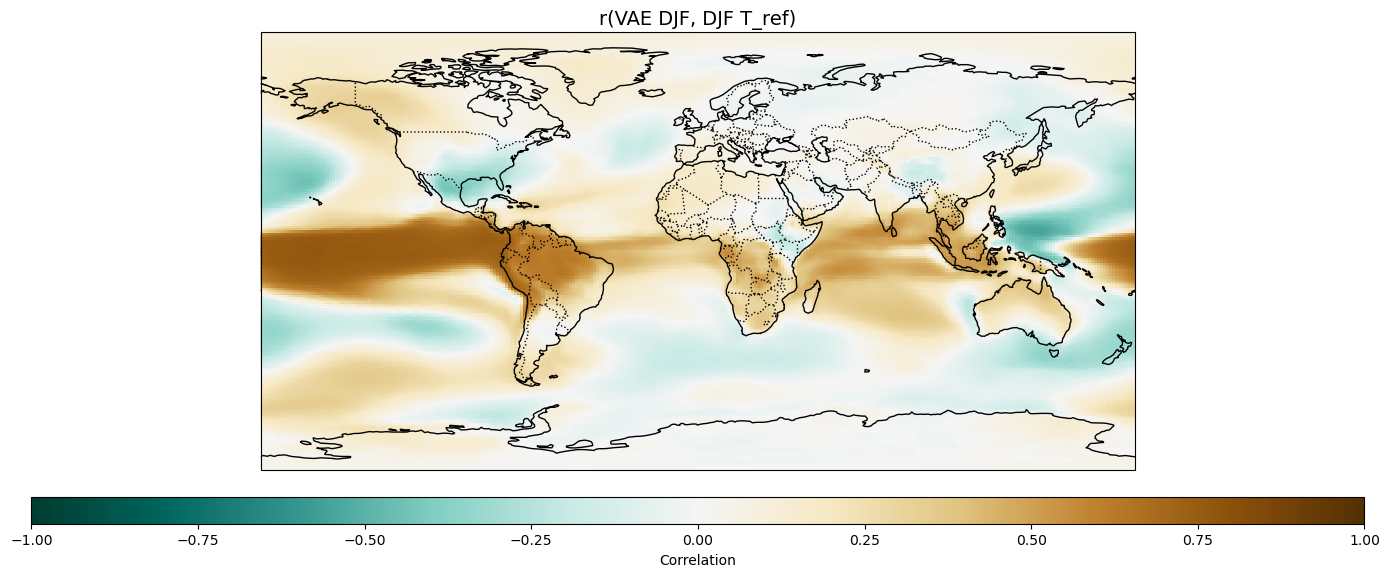

In [149]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# Assume you have:
# - corr_map: xr.DataArray with dims (lat, lon)
# - lat: 1D array of latitude values
# - lon: 1D array of longitude values

# 1. If not already in 2D: reshape the flat corr into (lat, lon)
corr_2d = corr.values.reshape(lat, lon) if corr.ndim == 1 else corr.values

# 2. Create 2D lat/lon grid
lons, lats = np.meshgrid(djf_anomalies.lon, djf_anomalies.lat)  # or from your dataset directly

# 3. Plot with Cartopy
fig = plt.figure(figsize=(14, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the data
pcm = ax.pcolormesh(lons, lats, corr_2d, cmap='BrBG_r', vmin=-1, vmax=1, transform=ccrs.PlateCarree())

# Add features
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_global()

# Colorbar and labels
cbar = plt.colorbar(pcm, orientation='horizontal', pad=0.05, aspect=50)
cbar.set_label('Correlation')

plt.title('r(VAE DJF, DJF T_ref)', fontsize=14)
plt.tight_layout()
#plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/teleconnections/corr_map_cartopy.png', dpi=450)
plt.show()

/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:856: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  self.set_xlim([x1, x2])
/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/glade/work/ewisinski/conda-envs/oldkeras/lib/python3.11/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


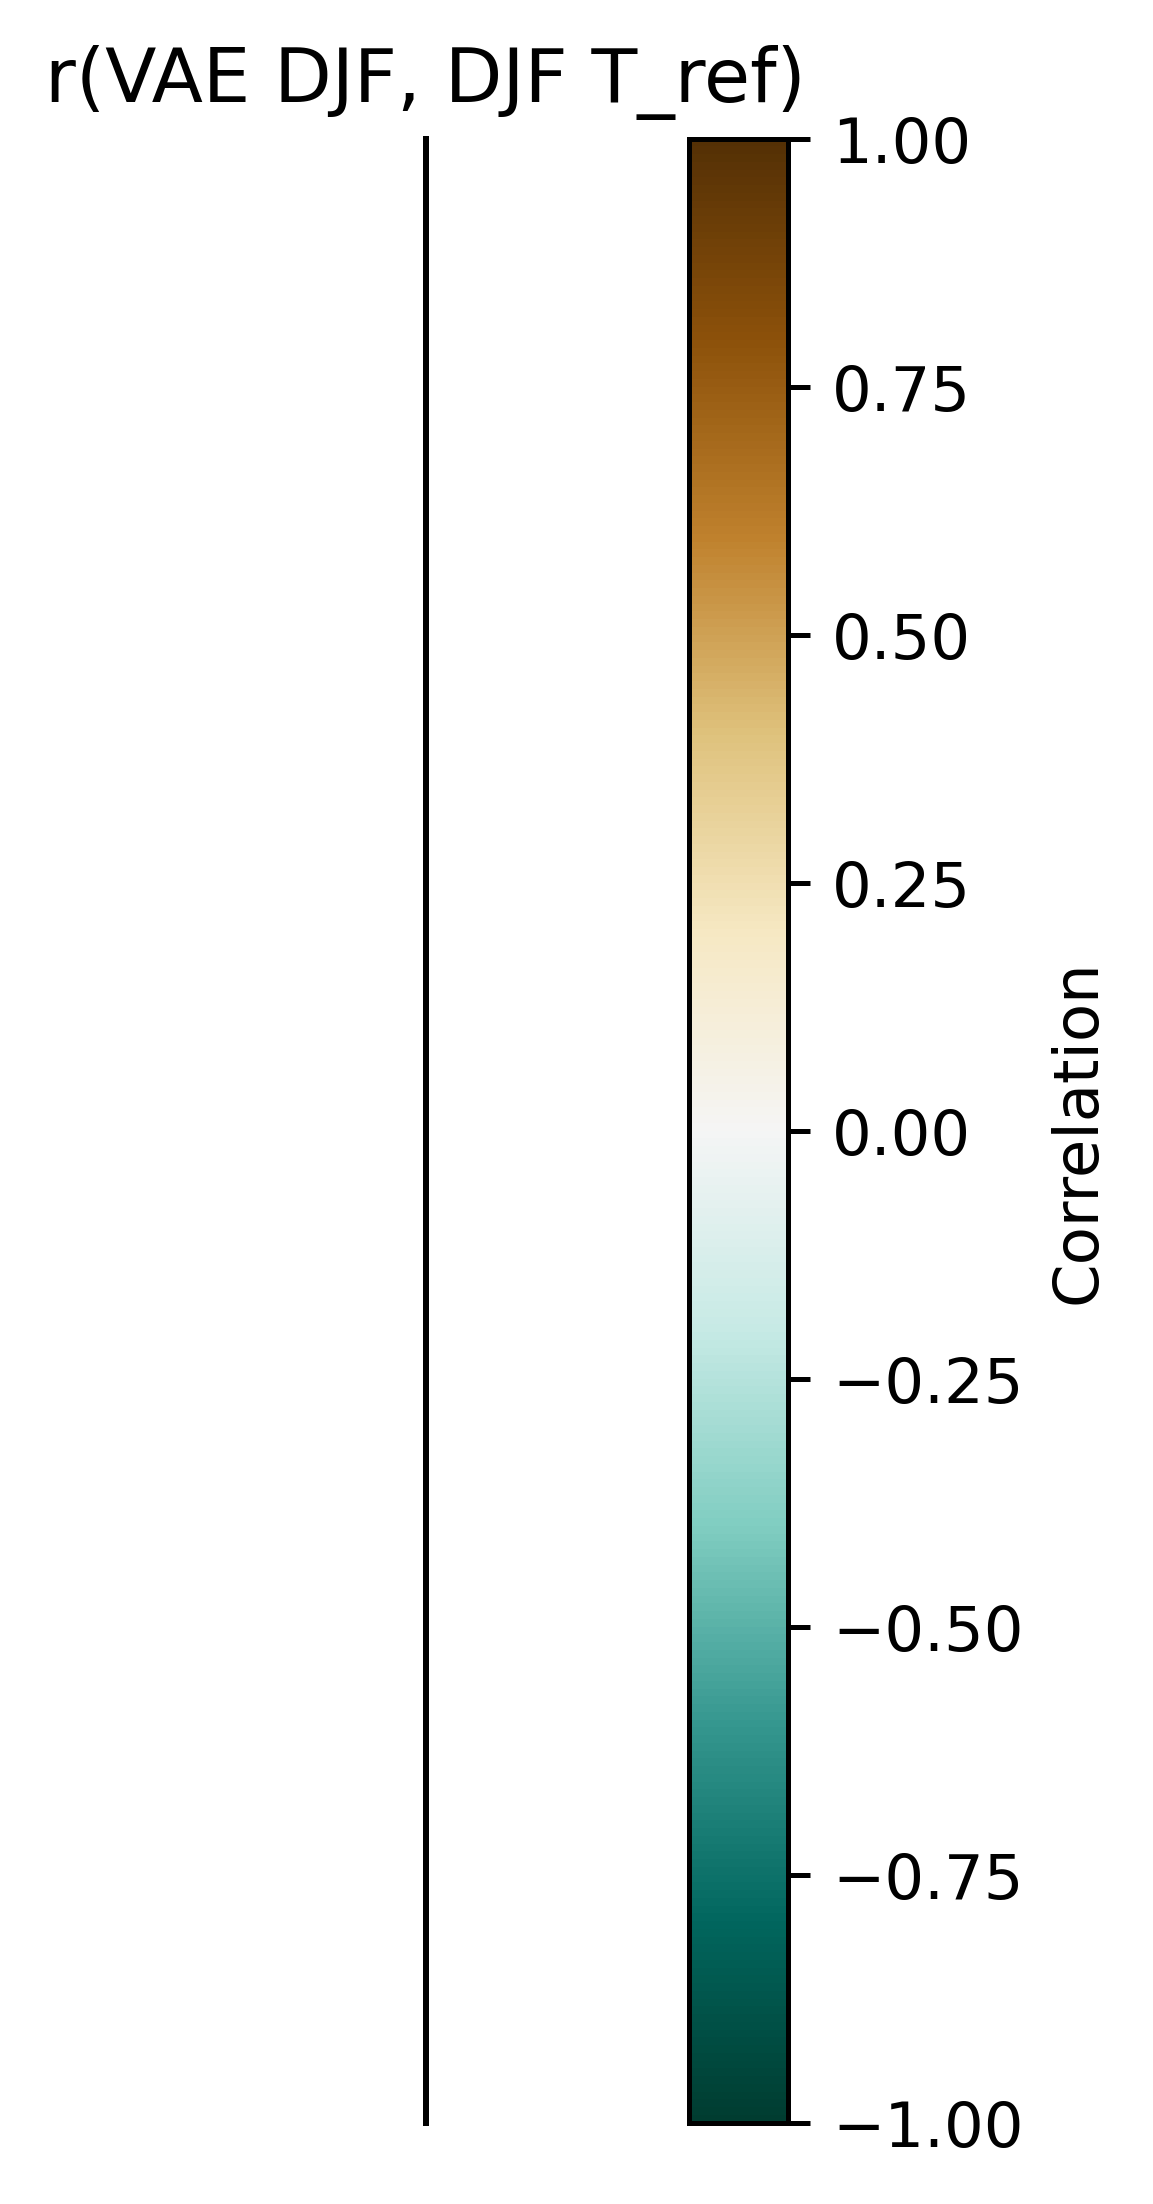

In [147]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

# Assume:
# - djf_anomalies is a Dask array of shape (499, 192, 288)
# - vae_djf_rolling['mean_0'].values is a NumPy array of shape (499,)
#   and already standardized

vae_mean = vae_djf_rolling['mean_0'].values  # standardized already

# Flatten lat/lon
djf_year, lat, lon = djf_anomalies_centered.shape

# Compute correlation (numerator of Pearson r)
numerator = (X * vae_mean[:, None]).mean(axis=0)

# Compute denominator (std of each spatial time series * std of vae_mean)
std_X = X.std(axis=0)
# std_y = 1 since vae_mean is already standardized

corr = numerator / std_X  # shape (192*288,)
# Assuming your correlation map is flattened (1D array of shape (192 * 288,))
corr_map = corr.values.reshape(lat, lon)  # Reshape to match lat/lon grid

# Plotting
fig, ax = plt.subplots(figsize=(12, 5), dpi=450, subplot_kw={'projection': ccrs.PlateCarree()})

# Draw coastlines and countries
ax.set_extent([0, 288, 0, 192]) # Global map extent
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot the correlation map
c = ax.imshow(corr_map, origin='lower', cmap=sns.color_palette("BrBG_r", as_cmap=True), vmin=-1, vmax=1)

# Add stippling for significant areas (thresholding at 0.5 correlation, for example)
threshold = 0.5
significant = np.abs(corr_map) > threshold
x, y = np.meshgrid(np.arange(lon), np.arange(lat))

# Plot stipples on significant correlations
ax.scatter(x[significant], y[significant], color='black', marker='.', alpha=0.3, s=10, transform=ccrs.PlateCarree())

# Add colorbar
plt.colorbar(c, ax=ax, label='Correlation')

# Title and labels
ax.set_title('r(VAE DJF, DJF T_ref)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('/glade/u/home/ewisinski/e3sm_autoencoder/standardscaler/newcoords/randomsampling/fromjohn/teleconnections/pearsonr_globalmap_significance.png', dpi=450, bbox_inches='tight', pad_inches=0.1)
plt.show()